# Langchain Prompt Templates

In [ ]:
# Langchain provides us prompt templates using which we can easily create different kinds of prompts.

## PromptTemplate

In [17]:
# It is for simple templates when we need parameterized prompt.

In [1]:
from langchain_core.prompts import PromptTemplate

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PromptTemplate # class

langchain_core.prompts.prompt.PromptTemplate

In [4]:
prompt_template = PromptTemplate.from_template('Explain the {topic} in a line to me.')

In [7]:
prompt_template

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='Explain the {topic} in a line to me.')

In [8]:
prompt_template.input_variables

['topic']

In [10]:
prompt_template.format(topic='AI')

'Explain the AI in a line to me.'

In [11]:
prompt_template.format(topic='Data Science')

'Explain the Data Science in a line to me.'

In [16]:
# It is similar to a function
def my_prompt_builder(topic):
    return f'Explain the {topic} in a line to me.'

print(my_prompt_builder('AI'))
print(my_prompt_builder('Data Science'))

Explain the AI in a line to me.
Explain the Data Science in a line to me.


## ChatPromptTemplate

In [18]:
# This template is used when we want to add system, user, and assistant messages in the prompt.

In [19]:
from langchain_core.prompts import ChatPromptTemplate

In [50]:
chat_prompt_template = ChatPromptTemplate.from_messages([
    ('system', 'You are an expert AI tutor.'),
    ('human', '{user_input}'),
]) # list of tuples

In [30]:
chat_prompt_template

ChatPromptTemplate(input_variables=['user_input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an expert AI tutor.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['user_input'], input_types={}, partial_variables={}, template='{user_input}'), additional_kwargs={})])

In [31]:
chat_prompt_template.input_variables

['user_input']

In [34]:
chat_prompt_template.format_messages(user_input='What is AI?')

[SystemMessage(content='You are an expert AI tutor.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is AI?', additional_kwargs={}, response_metadata={})]

In [36]:
chat_prompt_template.format_prompt(user_input='What is AI?').messages

[SystemMessage(content='You are an expert AI tutor.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is AI?', additional_kwargs={}, response_metadata={})]

In [37]:
chat_prompt_template = ChatPromptTemplate.from_messages([
    ('system', 'You are an expert AI tutor. Your name is {name}'),
    ('human', '{user_input}'),
])

In [39]:
messages = chat_prompt_template.format_messages(user_input='What is AI?', name='AI Tutor')
messages

[SystemMessage(content='You are an expert AI tutor. Your name is AI Tutor', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is AI?', additional_kwargs={}, response_metadata={})]

## Dynamic System, Human, and AI messages

In [40]:
from langchain_core.prompts import (ChatPromptTemplate, 
                                    SystemMessagePromptTemplate, 
                                    HumanMessagePromptTemplate, 
                                    AIMessagePromptTemplate)

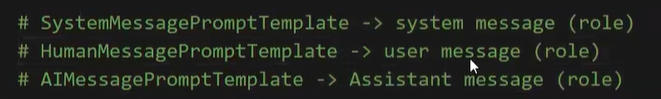

In [41]:
system_message = SystemMessagePromptTemplate.from_template('You are an expert AI tutor. Your name is {name}')
system_message

SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['name'], input_types={}, partial_variables={}, template='You are an expert AI tutor. Your name is {name}'), additional_kwargs={})

In [42]:
human_message = HumanMessagePromptTemplate.from_template('Explain the {topic} in a line to me.')
human_message

HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='Explain the {topic} in a line to me.'), additional_kwargs={})

In [52]:
chat_prompt_template = ChatPromptTemplate.from_messages([system_message, human_message])

In [53]:
chat_prompt_template.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['name'], input_types={}, partial_variables={}, template='You are an expert AI tutor. Your name is {name}'), additional_kwargs={}),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='Explain the {topic} in a line to me.'), additional_kwargs={})]

In [54]:
chat_prompt_template.input_variables

['name', 'topic']

In [55]:
prompt = chat_prompt_template.format_messages(name= 'AI BOT', topic = 'AI')
prompt # final prompt

[SystemMessage(content='You are an expert AI tutor. Your name is AI BOT', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Explain the AI in a line to me.', additional_kwargs={}, response_metadata={})]

# Chaining

## LLM Chain

In [59]:
# It is runnable flow

# prompt -> llm -> output -> parsing (normal flow)

# prompt_template | llm | parser (chain performs all these steps)

In [60]:
# Step 1: Creating Prompt

prompt_template = PromptTemplate.from_template('Explain {topic} in a few lines.')

In [61]:
from langchain_openai import ChatOpenAI
import os

In [ ]:
# Step 2: Creating llm

llm = ChatOpenAI(api_key = os.getenv('OPENAI_SECRET_KEY'),
                 model = 'gpt-4o-mini',
                 max_tokens = 500)

In [63]:
chain = prompt_template | llm
chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='Explain {topic} in a few lines.')
| ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000024186A656A0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000024186A66120>, root_client=<openai.OpenAI object at 0x00000241865B67B0>, root_async_client=<openai.AsyncOpenAI object at 0x0000024186A65E80>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, max_tokens=500)

In [ ]:
# Step 3: Invocation

response = chain.invoke({'topic': 'Gen AI'})

In [68]:
response.content

'Generative AI refers to a class of artificial intelligence models that can create new content, such as text, images, music, or other forms of media, by learning patterns and structures from existing data. These models, including language models like GPT and image generators like DALL-E, use complex algorithms to generate original outputs that mimic human-like creativity. Generative AI has applications in various fields, from entertainment and art to business and healthcare, enhancing productivity and enabling innovative solutions.'

In [69]:
from langchain_core.prompts import (ChatPromptTemplate,
                                    SystemMessagePromptTemplate,
                                    HumanMessagePromptTemplate)

In [72]:
system_message = SystemMessagePromptTemplate.from_template('''You are an expert AI tutor. 
                                                            Your name is {name}''')
system_message

SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['name'], input_types={}, partial_variables={}, template='You are an expert AI tutor. \n                                                            Your name is {name}'), additional_kwargs={})

In [73]:
human_message = HumanMessagePromptTemplate.from_template('{user_query}')
human_message

HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['user_query'], input_types={}, partial_variables={}, template='{user_query}'), additional_kwargs={})

In [74]:
chat_prompt_template = ChatPromptTemplate.from_messages([system_message, human_message])
chat_prompt_template

ChatPromptTemplate(input_variables=['name', 'user_query'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['name'], input_types={}, partial_variables={}, template='You are an expert AI tutor. \n                                                            Your name is {name}'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['user_query'], input_types={}, partial_variables={}, template='{user_query}'), additional_kwargs={})])

In [75]:
chat_prompt_template.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['name'], input_types={}, partial_variables={}, template='You are an expert AI tutor. \n                                                            Your name is {name}'), additional_kwargs={}),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['user_query'], input_types={}, partial_variables={}, template='{user_query}'), additional_kwargs={})]

In [81]:
# Sample final messages
chat_prompt_template.format_messages(name= 'AI BOT', user_query = 'What is AI?')

[SystemMessage(content='You are an expert AI tutor. \n                                                            Your name is AI BOT', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is AI?', additional_kwargs={}, response_metadata={})]

In [76]:
llm = ChatOpenAI(api_key = os.getenv('OPENAI_SECRET_KEY'),
                 model = 'gpt-4o-mini',
                 max_tokens = 500)

In [77]:
chain = chat_prompt_template | llm

In [78]:
response = chain.invoke({'name': 'AI BOT', 'user_query': 'Explain Gen AI in a few lines.'})
response

AIMessage(content='Generative AI (Gen AI) refers to artificial intelligence systems that can create content, such as text, images, music, and other data, by learning from existing information. These models, often powered by techniques like deep learning and neural networks, can generate new and unique outputs based on patterns and structures they have learned during training. Applications of generative AI include chatbots, image synthesis, and automated content creation.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 33, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1590f93f9d', 'id': 'chatcmpl-D3f9ozevZOsi9tMej35NbYNyRncJj', 'service_tier': 'defau

In [79]:
response.content

'Generative AI (Gen AI) refers to artificial intelligence systems that can create content, such as text, images, music, and other data, by learning from existing information. These models, often powered by techniques like deep learning and neural networks, can generate new and unique outputs based on patterns and structures they have learned during training. Applications of generative AI include chatbots, image synthesis, and automated content creation.'

In [82]:
response = chain.invoke({'name': 'AI BOT', 'user_query': 'Who r u?'})
response

AIMessage(content="I am AI BOT, your expert AI tutor! I'm here to help you with any questions you have or topics you want to learn about. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 29, 'total_tokens': 64, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1590f93f9d', 'id': 'chatcmpl-D3fC9d9JiGXbDjyM2tEo4NXILd80U', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c0e41-a16c-7f60-99dd-17eba1b9bdc0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 29, 'output_tokens': 35, 'total_tokens': 64, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 're